## For building a SynD model from my D1D2 MSM data

In this version: use stratified $k$-means clustering and a 100ps lagtime for a bad MSM but a good SynD propagation model.

In [1]:
import pickle
import numpy as np
from synd.models.discrete.markov import MarkovGenerator
from synd.core import load_model

In [2]:
from scipy import sparse
from scipy.cluster.vq import vq

In [3]:
import matplotlib.pyplot as plt
import deeptime
from tqdm.auto import tqdm
from mr_toolkit.clustering import StratifiedClusters
import mdap

### First, load features and create MSM

In [4]:
# load input feature data
oa1 = np.load("oa1.npy")
oa2 = np.load("oa2.npy")
tt = np.load("tt.npy")
m1x1 = np.load("m1x1.npy")
m2x1 = np.load("m2x1.npy")
c2 = np.load("c2.npy")

# processed and standardized features (in above order with chi angles split into sin/cos)
features = np.load("curated_features.npy")

In [5]:
features[0]

array([0.29875837, 0.3843302 , 0.40290088, 0.01654467, 0.72834116,
       0.59148152, 0.00992387, 0.26018641])

(<Figure size 1000x400 with 2 Axes>, <Axes: xlabel='TT', ylabel='C2'>)

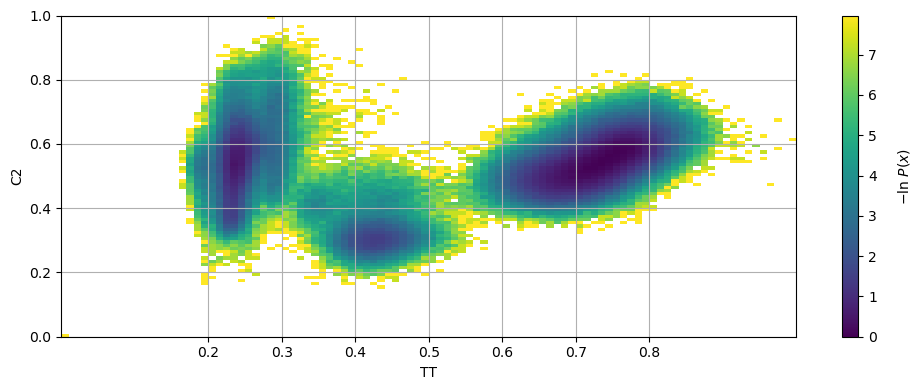

In [6]:
fig, ax = plt.subplots(figsize=(10,4))
ax.set_xticks(np.arange(0.2, 0.9, 0.1))
ax.grid(True)
mdap.MD_Plot(Xname=features[:,2], xlabel="TT", Xindex=0, 
             Yname=features[:,7], ylabel="C2", Yindex=0, data_type="pdist", ax=ax).plot()

(<Figure size 1000x400 with 2 Axes>, <Axes: xlabel='TT', ylabel='C2'>)

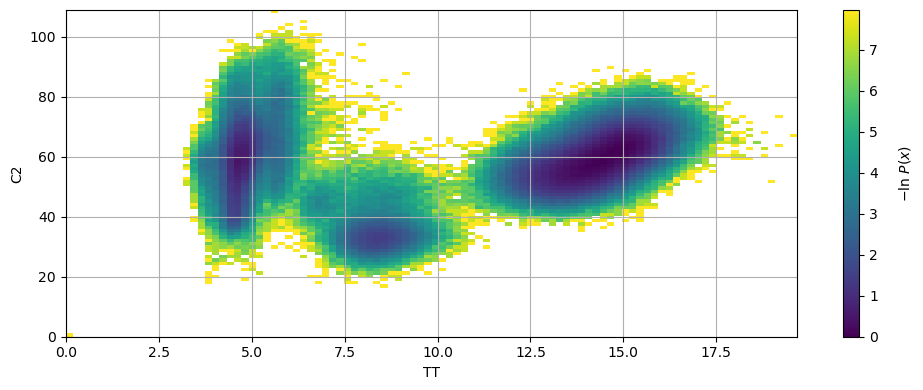

In [7]:
fig, ax = plt.subplots(figsize=(10,4))
ax.grid(True)
mdap.MD_Plot(Xname=tt, xlabel="TT", Xindex=0, 
             Yname=c2, ylabel="C2", Yindex=0, data_type="pdist", ax=ax).plot()

Seems like a 8 strata clustering should be good, as shown above. Maybe 200 clusters per strata?

In [8]:
# clusters per strata
n_clusters = 200
# bins in tt_dist space
bounds = list(np.arange(0.2, 0.9, 0.1))
len(bounds)

7

In [9]:
bounds

[0.2,
 0.30000000000000004,
 0.4000000000000001,
 0.5000000000000001,
 0.6000000000000001,
 0.7000000000000002,
 0.8000000000000003]

In [10]:
# clustering
clusterer = StratifiedClusters(n_clusters, bin_bounds=bounds)
clusterer.fit(features, coord_to_stratify=2)
discrete_data = clusterer.predict(features)

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

In [11]:
discrete_data

array([757, 710, 710, ..., 338, 542, 338])

In [12]:
clusterer.cluster_centers

array([[0.04946187, 0.21803574, 0.19399609, ..., 0.73767995, 0.07129998,
        0.48819053],
       [0.12504922, 0.09111178, 0.18965623, ..., 0.638415  , 0.0232759 ,
        0.560026  ],
       [0.06935759, 0.23161061, 0.19211926, ..., 0.47739953, 0.00113418,
        0.42763382],
       ...,
       [0.89913009, 0.60933871, 0.82322712, ..., 0.00822606, 0.69050686,
        0.68996281],
       [0.64611319, 0.80859157, 0.83067984, ..., 0.01458043, 0.72459845,
        0.63286603],
       [0.75240351, 0.58434938, 0.81641227, ..., 0.00518112, 0.51053595,
        0.63175817]])

In [13]:
# Construct the MSM, using 1 step / 100ps lagtime
msm = deeptime.markov.msm.MaximumLikelihoodMSM(lagtime=1)
msm_model = msm.fit(discrete_data).fetch_model()

In [14]:
# Save the MSM for future analysis
with open("2025-02-03-synd_msm_model.pkl", "wb") as f:
    pickle.dump([discrete_data, clusterer.cluster_centers, msm_model], f)

In [15]:
msm_model

MarkovStateModelCollection-139953081806912:[{'count_models': None,
                                            'reversible': True,
                                            'stationary_distributions': None,
                                            'transition_matrices': None,
                                            'transition_matrix_tolerance': 1e-06}]

Also make bMSM for error bars later:

In [16]:
from deeptime.markov.msm import BayesianMSM

In [ ]:
# Construct the bMSM, using 1 step / 100ps lagtime
estimator = deeptime.markov.TransitionCountEstimator(lagtime=1, count_mode='effective')
bmsm_model = BayesianMSM().fit_fetch(estimator.fit_fetch(discrete_data))

In [ ]:
# Save the MSM for future analysis
with open("2025-02-03-synd_bmsm_model.pkl", "wb") as f:
    pickle.dump([discrete_data, clusterer.cluster_centers, bmsm_model], f)

In [ ]:
bmsm_model

### SynD Time

In [18]:
# Read previous data
with open(f'2025-02-03-synd_msm_model.pkl','rb') as file:
    [final_cluster, cluster_centers, final_msm] = pickle.load(file)

### Define backmapping coordinates

Grab the frame corresponding to each cluster center:

In [19]:
# frame index of each cluster
frames, _ = vq(cluster_centers, features)
print(f"frame index per cluster:\n {frames}")

frame index per cluster:
 [540974 318618 571677 ... 139959 161840  70045]


I need to create a dict that maps each cluster to the pcoord space, e.g.
``` Python
{0: array([0.19300674, ...]),
 1: array([0.14842148, ...]),
 2: array([0.12663524, ...]),
 3: array([0.16085377, ...]),
 ...
```

In [20]:
oa1[frames]

array([ 2.02020001,  7.37969971,  3.98119998, ..., 52.33149719,
       37.97920227, 43.45270157])

In [21]:
oa1[frames].shape

(1600,)

In [22]:
# this should give me the original feat values at each cluster center
pcoords = np.column_stack((oa1[frames],
                           oa2[frames],
                           tt[frames],
                           c2[frames],
                           m1x1[frames],
                           m2x1[frames],
                           ))

In [23]:
pcoords.shape

(1600, 6)

In [24]:
# now I just need the keys of the dict, which is just the cluster index
c_index = [i for i in range(pcoords.shape[0])]

In [25]:
# okay, now make it into a dict
backmapper = dict(zip(c_index,pcoords))

In [26]:
backmapper

{0: array([  2.02020001,  12.29660034,   3.9089    ,  54.24559784,
        -82.15690613, -61.52149963]),
 1: array([  7.37969971,   5.94180012,   3.8194    ,  60.05989838,
        -74.86889648, -74.60649872]),
 2: array([  3.98119998,  13.4571991 ,   3.6627    ,  49.13280106,
        -65.66399384, -94.04949188]),
 3: array([  3.55290008,   1.96700001,   3.8915    ,  53.14749908,
        -72.79880524, -79.01629639]),
 4: array([  1.54460001,   6.0788002 ,   3.63740015,  59.42839813,
        -83.90730286, -68.06300354]),
 5: array([  3.66949987,   5.86190033,   3.53649998,  55.9088974 ,
        -85.74170685, -89.84700012]),
 6: array([  9.14579964,  21.09140015,   4.3253    ,  67.16850281,
        -83.24480438, -74.38539886]),
 7: array([  5.47019958,  12.61559963,   3.9705    ,  41.55390167,
        -65.82460022, -69.32150269]),
 8: array([  3.19880009,   5.90509987,   3.6093    ,  45.47990036,
        -63.32969666, -82.34409332]),
 9: array([  6.8046999 ,  10.79320049,   3.88980007,  6

In [27]:
backmapper.get

<function dict.get(key, default=None, /)>

### Looks good! Now how about the transition matrix?

In [28]:
final_msm.__dir__()

['_transition_matrices',
 '_stationary_distributions',
 '_reversible',
 '_count_models',
 '_transition_matrix_tolerance',
 '_current_model',
 '_is_reversible',
 '_ncv',
 '_lagtime',
 '_transition_matrix',
 '_eigenvalues',
 '_stationary_distribution',
 '_n_eigenvalues',
 '_count_model',
 '__module__',
 '__doc__',
 '__init__',
 'current_model',
 'n_connected_msms',
 'state_symbols',
 '_validate_model_index',
 'state_fractions',
 'state_fraction',
 'count_fractions',
 'count_fraction',
 'select',
 '__abstractmethods__',
 '_abc_impl',
 '_invalidate_caches',
 'count_model',
 'has_count_model',
 'koopman_model',
 'empirical_koopman_model',
 'to_koopman_model',
 'lagtime',
 'transition_matrix',
 'transition_matrix_tolerance',
 'update_transition_matrix',
 'reversible',
 'sparse',
 'n_states',
 'n_eigenvalues',
 'ncv',
 'submodel',
 'stationary',
 'stationary_distribution',
 'update_stationary_distribution',
 '_compute_eigenvalues',
 '_ensure_eigenvalues',
 '_compute_eigendecomposition',
 '_en

In [29]:
final_msm.transition_matrix.shape

(1600, 1600)

### Okay, now let's create and save a SynD model

In [30]:
synd_model = MarkovGenerator(
    transition_matrix=final_msm.transition_matrix,
    backmapper=backmapper.get,
    seed=None,
)

In [31]:
synd_model.save('d1d2-100ps-1600k.synd')

### Now use the model to generate "synthetic" data

To get a random D1-like state, can think about how the strata are organized, that is, a cluster in the second to last strata will likely be a reasonable starting structure. This might be e.g. 1200-1400 range.

In [32]:
# initial state at D1-like
pcoords[1360]

array([ 26.23830032,  38.31010056,  14.2372    ,  59.96389771,
       173.85380554, -77.70599365])

Note that each step is an MSM lagtime step. My lagtime here is 100ps.

In [33]:
%%time

# 1 us: 100ps * 10000 steps
trajectory = synd_model.generate_trajectory(
    initial_states=np.array([1360]),
    n_steps=10000,
)
trajectory

CPU times: user 75.8 ms, sys: 6 µs, total: 75.8 ms
Wall time: 75.1 ms


array([[1360, 1360, 1081, ...,  310,  367,  242]])

In [34]:
trajectory.shape

(1, 10000)

### Alternatively, start here: load a SynD model directly

In [35]:
loaded_model = load_model('d1d2-100ps-1600k.synd')

Here let's do 10µs.

In [36]:
%%time

trajectory = loaded_model.generate_trajectory(
    initial_states=np.array([1360]),
    n_steps=100000,
)
trajectory

CPU times: user 743 ms, sys: 1.99 ms, total: 745 ms
Wall time: 745 ms


array([[1360, 1360, 1081, ...,  357,  224,  269]])

### And backmap to pcoords

In [37]:
mapped_traj = synd_model.backmap(trajectory)

In [38]:
mapped_traj.shape

(1, 100000, 6)

In [39]:
mapped_traj

array([[[ 26.23830032,  38.31010056,  14.2372    ,  59.96389771,
         173.85380554, -77.70599365],
        [ 26.23830032,  38.31010056,  14.2372    ,  59.96389771,
         173.85380554, -77.70599365],
        [ 23.542099  ,  37.28929901,  13.2586    ,  62.81909943,
         174.21401978, -80.27250671],
        ...,
        [ 11.37649918,  19.41679955,   4.7728    ,  69.41429901,
         -71.30899048, -82.47330475],
        [ 15.31190014,  10.96570015,   4.64069986,  62.8234024 ,
         -67.90569305, -92.56050873],
        [ 17.97510147,  14.55280018,   4.75950003,  60.61370087,
         -47.32330322, -76.39859772]]])

In [40]:
mapped_traj[0].shape

(100000, 6)

In [41]:
mapped_traj[0][:,0]

array([26.23830032, 26.23830032, 23.542099  , ..., 11.37649918,
       15.31190014, 17.97510147])

### Make some plots

In [42]:
import matplotlib.pyplot as plt

In [43]:
steps=100000
# us x-units
#x = [i*20/1000 for i in range(steps)]
x = [i*100/1000/1000 for i in range(steps)]

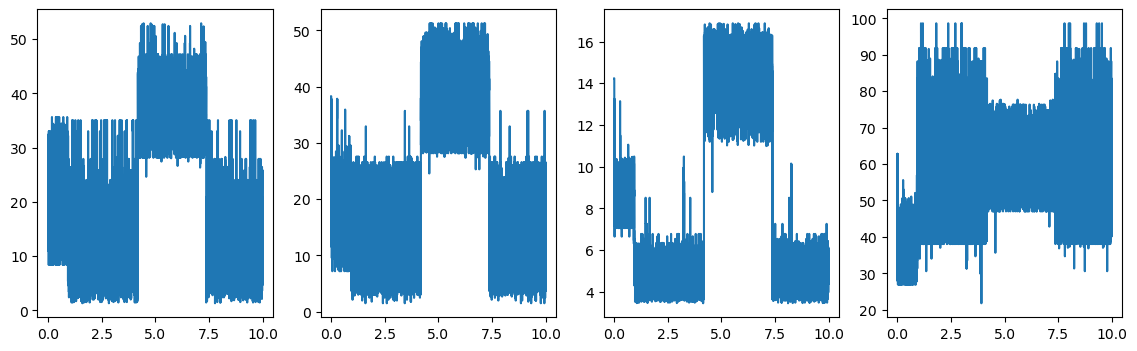

In [44]:
fig, ax = plt.subplots(ncols=4, figsize=(14,4))
ax[0].plot(x, mapped_traj[0][:steps,0])
ax[1].plot(x, mapped_traj[0][:steps,1])
ax[2].plot(x, mapped_traj[0][:steps,2])
ax[-1].plot(x, mapped_traj[0][:steps,3])

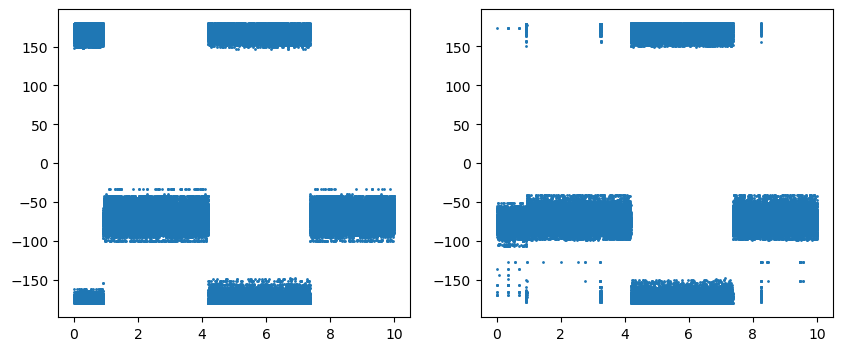

In [45]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
ax[0].scatter(x, mapped_traj[0][:steps,4], s=1)
ax[1].scatter(x, mapped_traj[0][:steps,5], s=1)

#### Pdists

In [46]:
import mdap

(<Figure size 640x480 with 2 Axes>, <Axes: >)

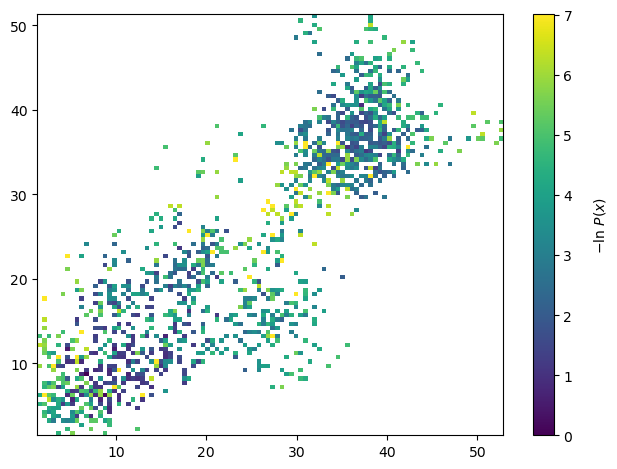

In [47]:
mdap.MD_Plot(Xname=mapped_traj[0][:,0], Xindex=0, Yname=mapped_traj[0][:,1], Yindex=0, data_type="pdist").plot()

---
Overall, the pdists and the trajectories look quite reasonable, and better than with my previous MSM.
---

---
#### Now assign state labels to each cluster center
Then get mfpt of the D1<-->D2 interconversion process

In [ ]:
backmapper

In [ ]:
d1 = []
d2 = []
neither = []
for ci, pcoords in backmapper.items():
    if pcoords[0] < 10 and pcoords[1] < 10 and pcoords[2] < 5 and pcoords[3] > 40 and -95 < pcoords[4] < -40 and -95 < pcoords[5] < -40:
        d2.append(ci)
    elif pcoords[0] > 32 and pcoords[1] > 32 and pcoords[2] > 13 and pcoords[3] > 40:
        d1.append(ci)
    else:
        neither.append(ci)

In [ ]:
len(d1), len(d2), len(neither)

(483, 162, 955)

In [ ]:
backmapper[1360]

array([ 26.23830032,  38.31010056,  14.2372    ,  59.96389771,
       173.85380554, -77.70599365])

#### MFPT from set A to set B (in units of input trajectory, which in this case is the MSM lagtime since using SynD traj)

In [ ]:
d1d2 = final_msm.mfpt(1360, d2)

In [53]:
d1d2 = final_msm.mfpt(d1, d2)

In [54]:
d1d2

43099.68899127107

In [55]:
d2d1 = final_msm.mfpt(d2, d1)

In [56]:
d1d2, d2d1

(43099.68899127107, 14517.140579437777)

In [57]:
d1d2, d2d1

(43099.68899127107, 14517.140579437777)

In [58]:
d2d1/d1d2

0.33682703794864777

In [59]:
1/d1d2

2.3202023573825064e-05

In [60]:
# mfpt in milliseconds (100ps MSM lagtime)
d1d2_mfpt = d1d2 * 100 / 1000 / 1000 / 1000
d2d1_mfpt = d2d1 * 100 / 1000 / 1000 / 1000
d1d2_mfpt

0.004309968899127107

In [61]:
# rate per s (exp is ~60/s)
1 / d1d2_mfpt

232.02023573825065

In [62]:
# rate per s (exp is ~120/s)
1 / d2d1_mfpt

688.8408874516308

---
## Okay, let's see if we can get errors from bMSM:

In [63]:
# Read previous data
with open(f'2025-02-03-synd_bmsm_model.pkl','rb') as file:
    [final_cluster, cluster_centers, final_bmsm] = pickle.load(file)

In [64]:
flux_d1d2 = final_bmsm.evaluate_samples('reactive_flux', source_states=d1, target_states=d2)

In [ ]:
flux_d2d1 = final_bmsm.evaluate_samples('reactive_flux', source_states=d2, target_states=d1)

In [ ]:
def calc_bmsm_flux_errors(bmsm_fluxes):
    """
    Returns the mean +/- std for bmsm reactive flux: 
    mean rate, std rate, mean mfpt, std mfpt
    """
    rates = []
    mfpts = []
    for m in bmsm_fluxes:
        rates.append(m.rate)
        mfpts.append(m.mfpt)
    return {"mean rate":np.mean(rates), "std rate":np.std(rates), 
            "mean mfpt":np.mean(mfpts), "std mfpt":np.std(mfpts)}

In [ ]:
calc_bmsm_flux_errors(flux_d1d2)

In [ ]:
calc_bmsm_flux_errors(flux_d2d1)

If you have some $X$ and its standard deviation $s$, then the derivative of $\frac{1}{X}$ w.r.t. $X$ is $\frac{-1}{X^2}$, and the standard deviation of $\frac{1}{X}$ is approximately $\frac{s}{X^2}$. The approximation gets worse as $s$ becomes larger relative to $X$.

For instance if X = 10±1, then 1/X is approximately 0.1±.01. (Which you can confirm by experiment, seeing that X=9 or X=11 maps to 1/X=0.111 and 1/X=0.091. X=8 or X=12 maps to 1/X=0.125 and 0.083)

In [ ]:
# error_k = error_mfpt / mfpt**2
3.28 / 93.46**2

Seems that either error propagation or percent error works.

In [ ]:
# percent error
a = 3.28 / 93.46
a, 0.010657 * a

### Now with mfpts directly (this is likely the better calc to go with)

In [ ]:
bd1d2 = final_bmsm.gather_stats('mfpt', A=d1, B=d2)
bd2d1 = final_bmsm.gather_stats('mfpt', A=d2, B=d1)

In [ ]:
bd1d2.mean, bd1d2.std

In [ ]:
bd2d1.mean, bd2d1.std

In [ ]:
# percent error
pe_d1d2 = bd1d2.std / bd1d2.mean
pe_d2d1 = bd2d1.std / bd2d1.mean

In [ ]:
pe_d1d2, pe_d2d1

In [ ]:
def convert(x):
    """
    For 100 ps lagtime, convert mfpt from msm lagtime to seconds.
    """
    return (x * 100) / 1000 / 1000 / 1000 / 1000

In [ ]:
# convert mfpt to seconds and then convert to rate
kd1d2 = 1 / convert(bd1d2.mean)
kd2d1 = 1 / convert(bd2d1.mean)

# error_k = error_mfpt / mfpt**2
#sd1d2 = bd1d2.std / bd1d2.mean**2
#sd2d1 = bd2d1.std / bd2d1.mean**2

# percent error
sd1d2 = kd1d2 * pe_d1d2
sd2d1 = kd2d1 * pe_d2d1

Now propagate error to get $K_{ex}=\frac{k_{12}}{k_{21}}$

In [ ]:
Kex = kd1d2 / kd2d1

Error propagation from division of rates:

Given $z = \frac{x}{y}$ :

$\frac{\Delta{Z}}{Z} = \sqrt{(\frac{\Delta{x}}{x})^2 + (\frac{\Delta{y}}{y})^2 + ...}$

Solving for $\Delta{Z}$:

In [ ]:
K_error = Kex * np.sqrt((sd1d2 / kd1d2)**2 + (sd2d1 / kd2d1)**2)

In [ ]:
kd1d2, kd2d1

In [ ]:
print(f"k_12 = {kd1d2:0.3f} ± {sd1d2:0.3f} s^{-1}")
print(f"k_21 = {kd2d1:0.3f} ± {sd2d1:0.3f} s^{-1}")
print(f"K_ex = {Kex:0.3f} ± {K_error:0.5f}")

In $ms^{-1}$ instead of $s^{-1}$:

In [ ]:
print(f"k_12 = {kd1d2/1000:0.3f} ± {sd1d2/1000:0.3f} ms^{-1}")
print(f"k_21 = {kd2d1/1000:0.3f} ± {sd2d1/1000:0.3f} ms^{-1}")
print(f"K_ex = {Kex:0.3f} ± {K_error:0.5f}")

These values are much too fast compared to the experimental values. 

Before it was:

```
k_12 = 872.377 ± 20.630 s^-1
k_21 = 2659.414 ± 92.775 s^-1
K_ex = 0.328 ± 0.01383
```

But this is expected since I have now a bad MSM with diverse clusters and a 100ps lagtime, which is much too short for the Markovian approx between microstates, from ITS it was 20ns.